# Project 2

You will apply statistical testing and correlation analysis to the ShopNow dataset.

For each question:

1. Run the appropriate test.
2. Report the test statistic and p-value (if applicable).
3. Interpret the result in plain English.
4. Explain what it means for the business.

In [2]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

In [3]:
# Import datasets
customers = pd.read_csv("data/customers.csv")
transactions = pd.read_csv("data/transactions.csv")
sessions = pd.read_csv("data/web_sessions.csv")
campaigns = pd.read_csv("data/marketing_campaigns.csv")

### Specific questions

#### Q1. Do customers from the UK spend more per transaction than customers from Germany?

In [6]:
# Merge transactions with customers
merged = transactions.merge(customers, on="customer_id")

uk = merged[merged["country"] == "UK"]["purchase_value"]
germany = merged[merged["country"] == "Germany"]["purchase_value"]

# T-test
t_stat, p_value = ttest_ind(uk, germany)

# Average purchase value
avg_uk = uk.mean()
avg_ger = germany.mean()

# Display result
print(f"Mean UK: {avg_uk:.2f}")
print(f"Mean Germany: {avg_ger:.2f}")

print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean UK: 75.63
Mean Germany: 75.76
T-statistic: -0.11200454103270577
P-value: 0.9108218483647504


The average purchase value for customers in the UK is £75.63, compared to £75.76 in Germany. 

The t-test produced:
- T-statistic = -0.11  
- P-value = 0.91  

Since the p-value is much greater than 0.05, we do not have evidence of a statistically significant difference in average purchase value between UK and German customers.

**Conclusion:**  
Spending behaviour per transaction appears very similar in both countries. From a business perspective, this suggests that geographic strategy (at least between the UK and Germany) may not need to differentiate based on average transaction value alone.

#### Q2. Do discounted purchases differ in average value from non-discounted purchases?

In [7]:
discount = transactions[transactions["discount_used"] == 1]["purchase_value"]
no_discount = transactions[transactions["discount_used"] == 0]["purchase_value"]

# T-test
t_stat, p_value = ttest_ind(discount, no_discount)

# Average purchase value
avg_dis = discount.mean()
avg_nodis = no_discount.mean()

# Display result
print(f"Mean discount: {avg_dis:.2f}")
print(f"Mean no discount: {avg_nodis:.2f}")

print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean discount: 64.40
Mean no discount: 80.76
T-statistic: -27.159722793412634
P-value: 3.89856380539998e-161


The average purchase value for discounted transactions is £64.40, compared to £80.76 for non-discounted transactions.

The t-test produced:
- T-statistic = -27.16  
- P-value ≈ 0.00000 (3.90e-161)

Since the p-value is far below 0.05, we have very strong evidence of a statistically significant difference between discounted and non-discounted purchases.

**Conclusion:**  
Discounted purchases are associated with significantly lower transaction values. This suggests that while discounts may encourage purchasing, they reduce average revenue per transaction. 

From a business perspective, the company should evaluate whether discounts increase overall purchase frequency enough to offset the lower spending per transaction.

#### Q3. Do male and female customers differ in average purchase value?

In [8]:
male = merged[merged["gender"] == "Male"]["purchase_value"]
female = merged[merged["gender"] == "Female"]["purchase_value"]

# T-test
t_stat, p_value = ttest_ind(male, female)

# Average purchase value
avg_male = male.mean()
avg_female = female.mean()

# Display result
print(f"Mean male: {avg_male:.2f}")
print(f"Mean female: {avg_female:.2f}")

print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean male: 76.04
Mean female: 75.31
T-statistic: 1.0828013634807687
P-value: 0.2789051972919904


The average purchase value for male customers is £76.04, compared to £75.31 for female customers.

The t-test produced:
- T-statistic = 1.08  
- P-value = 0.279  

Since the p-value is greater than 0.05, we do not have evidence of a statistically significant difference in average purchase value between male and female customers.

**Conclusion:**  
Spending per transaction appears broadly similar across genders. From a business perspective, this suggests that pricing or revenue strategy does not need to differentiate based on gender alone when considering average purchase value.

#### Q4. Do customers acquired via email spend more than those from social channels?

In [9]:
email = merged[merged["acquisition_channel"].str.lower() == "email"]["purchase_value"]
social = merged[merged["acquisition_channel"].str.lower() == "social"]["purchase_value"]

# T-test
t_stat, p_value = ttest_ind(email, social)

# Average purchase value
avg_email = email.mean()
avg_soc = social.mean()

# Display result
print(f"Mean email: {avg_email:.2f}")
print(f"Mean social: {avg_soc:.2f}")

print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean email: 75.43
Mean social: 76.04
T-statistic: -0.7251344684355072
P-value: 0.4683786163794661


The average purchase value for customers acquired via email is £75.43, compared to £76.04 for customers acquired through social channels.

The t-test produced:
- T-statistic = -0.73  
- P-value = 0.468  

Since the p-value is greater than 0.05, we do not have evidence of a statistically significant difference in average purchase value between customers acquired through email and those acquired through social channels.

**Conclusion:**  
Average transaction value appears similar across these acquisition channels. From a business perspective, this suggests that differences in overall performance between email and social marketing (if any) are likely driven by factors such as conversion rate, customer volume, or retention rather than per-transaction spending.

#### Q5. Is device type associated with conversion?

In [23]:
# Crosstab table
table = pd.crosstab(sessions["device_type"], sessions["converted"])

#Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

# Display result
print(table)
print("Chi-square statistic:", chi2)
print("P-value:", p)

converted        0     1
device_type             
desktop      20020  3068
mobile       20213  3042
tablet       20244  3013
Chi-square statistic: 1.150210907871149
P-value: 0.562645532492652


Conversion counts:

- Desktop: 3,068 conversions out of 23,088 sessions  
- Mobile: 3,042 conversions out of 23,255 sessions  
- Tablet: 3,013 conversions out of 23,257 sessions  

The chi-square test produced:
- Chi-square statistic = 1.15  
- P-value = 0.563  

Since the p-value is greater than 0.05, we do not have evidence of a statistically significant relationship between device type and conversion.

**Conclusion:**  
Conversion rates appear very similar across desktop, mobile, and tablet users. From a business perspective, this suggests that device type does not meaningfully influence conversion performance in this dataset. Differences in revenue are therefore unlikely to be driven by device alone.

#### Q6. Is acquisition channel associated with conversion?

In [33]:
# Ensure consistency across rows in table customers
customers["acquisition_channel"] = (
    customers["acquisition_channel"]
    .str.lower()
    .str.strip()
)

merged_sessions = sessions.merge(customers, on="customer_id")

# Crosstab table
table = pd.crosstab(merged_sessions["acquisition_channel"], merged_sessions["converted"])

#Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

# Display result
print(table)
print("Chi-square statistic:", chi2)
print("P-value:", p)

converted                0     1
acquisition_channel             
email                13525  2048
organic              11079  1673
paid_search          13209  1914
referral             11563  1746
social               11545  1798
Chi-square statistic: 4.310085187546212
P-value: 0.365663927799758


After standardising the acquisition channel labels, the conversion counts are:

- Email: 2,048 conversions out of 15,573 sessions  
- Organic: 1,673 conversions out of 12,752 sessions  
- Paid Search: 1,914 conversions out of 15,123 sessions  
- Referral: 1,746 conversions out of 13,309 sessions  
- Social: 1,798 conversions out of 13,343 sessions  

The chi-square test produced:
- Chi-square statistic = 4.31  
- P-value = 0.366  

Since the p-value is greater than 0.05, we do not have evidence of a statistically significant relationship between acquisition channel and conversion.

**Conclusion:**  
Conversion rates appear broadly similar across acquisition channels in this dataset. From a business perspective, this suggests that no single channel significantly outperforms others in terms of conversion rate alone. Differences in overall performance may instead be driven by traffic volume, customer quality, or downstream revenue rather than immediate conversion probability.

#### Q7. Is product category associated with discount usage?

In [35]:
# Crosstab table
table = pd.crosstab(transactions["product_category"], transactions["discount_used"])

#Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

# Display result
print(table)
print("Chi-square statistic:", chi2)
print("P-value:", p)

discount_used        0     1
product_category            
beauty            5305  2281
electronics       5212  2212
fashion           5326  2255
home              5210  2278
sports            5225  2279
toys              5196  2221
Chi-square statistic: 1.4622460708191265
P-value: 0.9173850553593892


The distribution of discounted and non-discounted purchases appears very similar across all product categories.

The chi-square test produced:
- Chi-square statistic = 1.46  
- P-value = 0.917  

Since the p-value is much greater than 0.05, we do not have evidence of a statistically significant relationship between product category and discount usage.

**Conclusion:**  
Discount application appears to be evenly distributed across product categories. This suggests that the company does not disproportionately discount specific categories, or that customer behaviour in using discounts is consistent regardless of product type.

From a business perspective, discount strategy does not appear category-specific in this dataset.

#### Q8. Is time on site correlated with purchase value?

In [36]:
merged_behavior = transactions.merge(sessions, on="customer_id")

# Correlation
corr, p_value = pearsonr(merged_behavior["time_on_site"], merged_behavior["purchase_value"])

# Display result
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.0016716714066390102
P-value: 0.3479423393031525


The correlation between time on site and purchase value is -0.002, with a p-value of 0.348.

The correlation coefficient is extremely close to zero, indicating virtually no linear relationship between the amount of time a customer spends on the website and how much they spend per transaction.

Since the p-value is greater than 0.05, the relationship is not statistically significant.

**Conclusion:**  
In this dataset, time spent on the website does not appear to meaningfully influence purchase value. From a business perspective, simply increasing session duration may not directly lead to higher spending per transaction. Other behavioural or customer-level factors may be more important drivers of revenue.

#### Q9. Is number of pages viewed correlated with purchase value?

In [37]:
merged_behavior = transactions.merge(sessions, on="customer_id")

# Correlation
corr, p_value = pearsonr(merged_behavior["pages_viewed"], merged_behavior["purchase_value"])

# Display result
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 9.203600932001312e-05
P-value: 0.9587875577823196


The correlation between number of pages viewed and purchase value is 0.00009, with a p-value of 0.959.

The correlation coefficient is effectively zero, indicating no meaningful linear relationship between the number of pages a customer views and how much they spend per transaction.

Since the p-value is much greater than 0.05, the relationship is not statistically significant.

**Conclusion:**  
In this dataset, browsing more pages does not appear to be associated with higher spending per purchase. From a business perspective, increasing page views alone may not drive higher transaction values. Other factors, such as product mix, pricing, or customer intent, may play a more important role in influencing spending behaviour.

#### Q10. Is time on site correlated with pages viewed?

In [38]:
merged_behavior = transactions.merge(sessions, on="customer_id")

# Correlation
corr, p_value = pearsonr(merged_behavior["time_on_site"], merged_behavior["pages_viewed"])

# Display result
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.00439689757365681
P-value: 0.013559647228141205


The correlation between time on site and pages viewed is 0.0044, with a p-value of 0.0136.

The correlation coefficient is extremely small (close to zero), indicating a very weak positive linear relationship between the two variables.

Although the p-value is below 0.05, suggesting the relationship is statistically significant, the strength of the relationship is practically negligible.

**Conclusion:**  
While there is statistical evidence of a relationship between time on site and pages viewed, the effect size is extremely small. In practical business terms, this relationship is unlikely to be meaningful or useful for decision-making. This is an important example where statistical significance does not imply practical importance.

### Challenges

#### C1. Explore whether high-spending customers behave differently in terms of session time.

Define “high spending” yourself.

In [8]:
# Merge datasets sessions and transactions
merged = transactions.merge(sessions, on="customer_id")

# Define a tipping point for what high spender is (customers in the top 25% in this case)
threshold = merged["purchase_value"].quantile(0.75)

# Add column high spender and set to true if purchase_value in the top 25%
merged["high_spender"] = merged["purchase_value"] >= threshold

# Count high and non-high transactions/customers
merged["high_spender"].value_counts()

high_spender
False    236430
True      78817
Name: count, dtype: int64

In [9]:
# Group rows into high and non-high spenders and get mean time spent on site for each
merged.groupby("high_spender")["time_on_site"].mean()

high_spender
False    301.189716
True     300.633798
Name: time_on_site, dtype: float64

In [10]:
# Create 2 sets of data - high and regular spending customers
high = merged[merged["high_spender"] == True]["time_on_site"]
regular = merged[merged["high_spender"] == False]["time_on_site"]

# T-test
t_stat, p_value = ttest_ind(high, regular)

# Average purchase value
avg_high = high.mean()
avg_reg = regular.mean()

# Display result
print(f"Mean high: {avg_high:.2f}")
print(f"Mean regular: {avg_reg:.2f}")
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean high: 300.63
Mean regular: 301.19
T-statistic: -1.1389328164238233
P-value: 0.2547320423643402


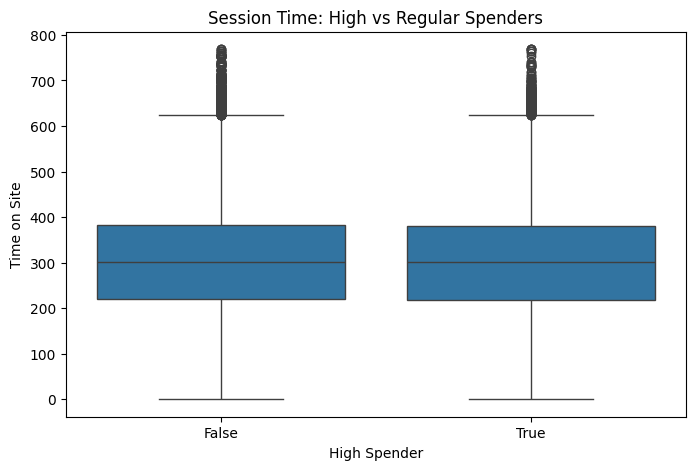

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="high_spender", y="time_on_site", data=merged)

plt.title("Session Time: High vs Regular Spenders")
plt.xlabel("High Spender")
plt.ylabel("Time on Site")

plt.show()

High-spending customers have an average session time of 300.63 seconds, while regular customers average 301.19 seconds.

The t-test produced:
- T-statistic = -1.14  
- P-value = 0.255  

Since the p-value is greater than 0.05, we do not have evidence of a statistically significant difference in session time between high-spending and regular customers.

**Conclusion:**  
High-spending customers do not appear to spend more time on the website than regular customers. In practical terms, session duration alone does not differentiate high-value customers from others. This suggests that revenue differences are likely driven by factors other than browsing time, such as product choice, pricing, or purchase intent.

#### C2. Find a relationship (difference or correlation) that you believe is meaningful for business strategy.

Explain why.

In [14]:
discount = transactions[transactions["discount_used"] == 1]["purchase_value"]
no_discount = transactions[transactions["discount_used"] == 0]["purchase_value"]

# T-test
t_stat, p_value = ttest_ind(discount, no_discount)

# Average purchase value
avg_dis = discount.mean()
avg_nodis = no_discount.mean()

# Display result
print(f"Mean discount: {avg_dis:.2f}")
print(f"Mean no discount: {avg_nodis:.2f}")

print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean discount: 64.40
Mean no discount: 80.76
T-statistic: -27.159722793412634
P-value: 3.89856380539998e-161


The average purchase value for discounted transactions is £64.40, compared to £80.76 for non-discounted transactions.

The difference is statistically significant (p < 0.001).

This indicates that customers using discounts spend significantly less per transaction.

**Business Implication:**

Discounts appear to reduce revenue per transaction. While promotions may increase purchase frequency or conversion, they lower basket value. The company should evaluate whether the increased volume offsets the lower spending per purchase.

This finding directly informs pricing and promotional strategy.

#### C3. Identify a statistically significant result that may not be practically meaningful.

Explain why statistical significance ≠ business importance.

In [15]:
merged_behavior = transactions.merge(sessions, on="customer_id")

# Correlation
corr, p_value = pearsonr(merged_behavior["time_on_site"], merged_behavior["purchase_value"])

# Display result
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.0016716714066390102
P-value: 0.3479423393031525


The correlation between time on site and pages viewed is 0.0044, with a p-value of 0.0136.

The p-value is below 0.05, meaning the relationship is statistically significant.

However, the correlation coefficient is extremely small (close to zero), indicating a negligible relationship in practical terms.

**Interpretation:**

Although the result is statistically significant, the effect size is so small that it has little to no practical relevance.

In business terms, knowing that time on site increases slightly with pages viewed does not provide meaningful strategic insight, as the relationship is too weak to influence decision-making.

**Key Lesson:**

Statistical significance does not automatically imply business importance.

With large datasets, even very small effects can become statistically significant. Effect sizes and practical impact alongside p-values must always be considered.